#  Outlier Analysis

An outlier analysis framework breaks down data deviations, detection techniques, and treatment strategies as follows.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv('customer_churn.csv')
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


### 1. What is an Outlier?
An outlier is an observation that lies an abnormal distance from other values in a random sample of a population, significantly deviating from the overall distribution trend.

Example:

In customer_churn.csv, the median Total Charges is $3,830.98$, but long-tenure  account  holders  reach  up  to $15,559.29$, forming an extended upper tail.

#### AI/ML Usage:

Outliers warp distance metrics in models like K-Means clustering and distort optimization in Linear/Logistic Regression, leading to biased coefficients and poorer generalization.

In [3]:
extreme_customers = df[df['TotalCharges'] > 14000][['CustomerID', 'TenureYears', 'TotalCharges']]
print("\nExtreme TotalCharges Observations:")
print(extreme_customers.head())


Extreme TotalCharges Observations:
    CustomerID  TenureYears  TotalCharges
87   CUST00088           10      14708.04
98   CUST00099           10      15184.41
346  CUST00347           10      14382.92
416  CUST00417           10      14352.86
450  CUST00451           10      15395.20


### 2. Why Outliers Occur

Outliers originate either from data collection errors (human typos, pipeline corruption, system glitches) or true natural variation (inherent diversity in customer behavior).

Example:

* Data-Entry Error: A support desk agent accidentally entering 99 for SupportCalls.

* Natural Variation: High-value enterprise customers maintaining 10-year accounts with premium add-ons, driving high TotalCharges.

#### AI/ML Usage

Distinguishing the root cause guides feature engineering: data collection errors should be sanitized, whereas natural extreme signals (e.g., high churn risk among frequent support call clients) must be preserved.

### 3. Types of Outliers

### Univariate Outliers

An extreme data point evaluated within a single variable without considering other attributes.

Example:

A customer with SupportCalls = 9 when 75% of customers place 3 or fewer support calls.

#### AI/ML Usage

Univariate outliers distort distribution skewness and invalidate standard normalization routines like StandardScaler.

### Multivariate Outliers

An anomalous combination of two or more feature values that appears abnormal when considered together, even if each individual value is typical on its own.

Example: 

A customer with TenureYears = 0 (new user) who has TotalCharges = $8,000$. Individually, $8,000$ total charges and 0 years tenure exist in the dataset, but together they are contradictory.

#### AI/ML Usage

Detected using multi-dimensional models such as Isolation Forests or Mahalanobis Distance to prevent multi-collinearity distortions in complex classifiers.

### 4. Detection Techniques

### IQR Method (Interquartile Range)

A non-parametric detection technique where points outside $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ are flagged as outliers.

Example: 

Setting upper boundaries on TotalCharges in churn analysis without relying on normal distribution assumptions.

#### AI/ML Usage

Ideal for non-Gaussian, skewed continuous data.

In [6]:
q1 = df['TotalCharges'].quantile(0.25)
q3 = df['TotalCharges'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = Q3_val = q3 + 1.5 * iqr

iqr_outliers = df[(df['TotalCharges'] < lower_bound) | (df['TotalCharges'] > upper_bound)]
print(f"IQR Upper Bound: ${upper_bound:.2f}")
print(f"Total IQR Outliers in TotalCharges: {len(iqr_outliers)}")

IQR Upper Bound: $14468.09
Total IQR Outliers in TotalCharges: 23


### Z-Score Method

Measures how many standard deviations ($\sigma$) a data point deviates from the mean ($\mu$): $Z = \frac{x - \mu}{\sigma}$. Values where $\vert{}Z\vert{} > 3$ are flagged as outliers.

Example:

Screening continuous customer attributes under Gaussian assumptions to flag values past 3 standard deviations.

#### AI/ML Usage

Effective for normally distributed features, but sensitive to extreme values since the mean and standard deviation are themselves affected by outliers.

In [9]:
df1 = pd.read_csv('customer_churn.csv').dropna(subset=['TotalCharges'])

# Calculate absolute Z-scores
z_scores = np.abs(stats.zscore(df1['TotalCharges']))
z_outliers = df1[z_scores > 3]

print(f"Z-Score Outliers in TotalCharges (|Z| > 3): {len(z_outliers)}")
print(z_outliers[['CustomerID', 'TotalCharges']].head())

Z-Score Outliers in TotalCharges (|Z| > 3): 9
     CustomerID  TotalCharges
98    CUST00099      15184.41
450   CUST00451      15395.20
527   CUST00528      15559.29
910   CUST00911      15471.10
1487  CUST01488      15481.88


### Box Plot (Visualization)

A visual representation of feature distributions highlighting the median, quartiles, and points beyond the $1.5 \times IQR$ boundaries.

Example: 

Comparing total charges across customer subscription plans visually.

#### AI/ML Usage

Fast exploratory visual tool used during data preprocessing to detect skewness and extreme observations across categories.

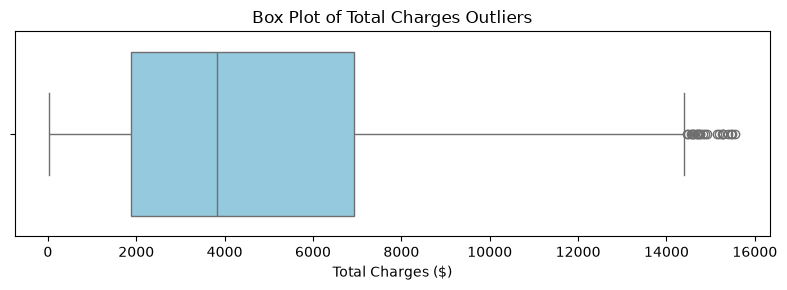

In [11]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['TotalCharges'], color='skyblue')
plt.title('Box Plot of Total Charges Outliers')
plt.xlabel('Total Charges ($)')
plt.tight_layout()
plt.show()

### Scatter Plot (Visualization)
A 2D visualization plotting pairs of continuous variables to uncover non-linear patterns, structural clusters, and isolated bivariate outliers.

Example: 

Plotting TenureYears against TotalCharges to verify whether customer billings scale logically with length of service.

#### AI/ML Usage

Used in bivariate analysis to spot relationship violations before feeding features into regression models.

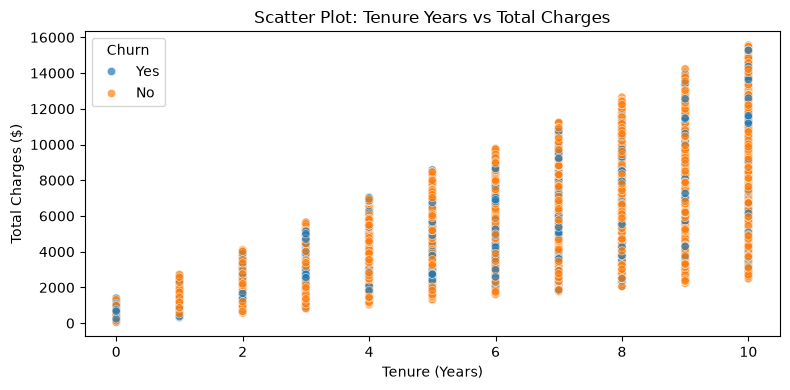

In [12]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='TenureYears', y='TotalCharges', hue='Churn', alpha=0.7)
plt.title('Scatter Plot: Tenure Years vs Total Charges')
plt.xlabel('Tenure (Years)')
plt.ylabel('Total Charges ($)')
plt.tight_layout()
plt.show()

### 5. Outlier Evaluation & Treatment Decisions
### Evaluation Diagnostics

* Is it a genuine observation?

  Yes. High TotalCharges ($15,000+) correspond to customers with 9–10 years of continuous service.
  
* Is it a data-entry error?

  No obvious typos were detected in this subset, though missing values (NaN) in TotalCharges require imputation or removal.

* Is it an unusual but valid observation?

   High support call rates ($\ge 7$) are unusual, but represent dissatisfied customers at high risk of churning.

* Should it be removed?

   Remove only if verified as a data-entry typo or corrupted pipeline artifact.

* Should it be transformed?

   Apply Log Transformation ($\log(x+1)$) or Windsorization (capping values at the $99^{\text{th}}$ percentile) to moderate skewness without dropping samples.

* Should it be retained?

  Retain valid high-value accounts or high support call cases, especially when utilizing tree-based algorithms (e.g., Random Forest, XGBoost) that are inherently robust to monotonic outlier effects.

* Documenting Reasoning:

  Always log why an outlier was removed, transformed, or retained in the preprocessing workflow to maintain pipeline auditability.